# Lab 3 - CNNs Applied

### Welcome to this lab notebook on image classification using CNNs. We will implement some of the best practices for this type of deep learning archictecture and we will visualize trained CNNs to better understand the role of filters and convolutions

Let's get started!


### 1. Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

### 2. Device Setup: Use GPU if available, otherwise fallback to CPU.

**Task 1. Include the code**

In [2]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Number of GPUs:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Final device setting: {device}")

PyTorch version: 2.7.1+cu118
CUDA available: True
CUDA version: 11.8
Number of GPUs: 1
GPU name: NVIDIA GeForce RTX 3060 Laptop GPU
Final device setting: cuda


### 3.  Data Loading and Preprocessing

The dataset used here is CIFAR-10, a well-known benchmark dataset in computer vision.
It consists of 60,000 color images of size 32x32 pixels, divided into 10 classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck).

There are 50,000 training images and 10,000 test images.


In [3]:
# ------------------------------------------------------------------------------
# Data Augmentation and Normalization for Training
# ------------------------------------------------------------------------------
transform_train = transforms.Compose([
    # Randomly crops the image to 32x32 with a padding of 4 pixels.
    # Rationale:
    # - Adds slight variations in image positioning to prevent the model from 
    #   overfitting to specific pixel locations.
    # - Helps the model become more robust to spatial variations in objects.
    # - The padding (4 pixels) temporarily increases image size to 40x40, from 
    #   which a random 32x32 region is cropped.
    transforms.RandomCrop(32, padding=4),  

    # Randomly flips images horizontally with a probability of 0.5.
    # Rationale:
    # - Introduces flip-based augmentation, making the model invariant to 
    #   left-right orientations of objects.
    # - Prevents over-reliance on specific left-right patterns in the dataset.
    # - Horizontal flipping is suitable for CIFAR-10 classes like cars, animals, 
    #   and ships, but vertical flipping is avoided as it might distort object meaning.
    transforms.RandomHorizontalFlip(),     

    # Converts images from PIL format to PyTorch tensors.
    # Rationale:
    # - Converts image data from integer values (0-255) to floating-point values (0-1).
    # - Enables PyTorch operations for deep learning models.
    transforms.ToTensor(),                 

    # Normalizes images using CIFAR-10's channel-wise mean and standard deviation.
    # Rationale:
    # - Standardizes the dataset to improve training stability.
    # - Ensures that all input features have a consistent scale, reducing issues with 
    #   different ranges of pixel intensities.
    # - The mean and std values were computed from the CIFAR-10 dataset:
    #   - Mean: [0.4914, 0.4822, 0.4465] (R, G, B channels)
    #   - Std:  [0.2470, 0.2435, 0.2616] (R, G, B channels)
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],  
                         std=[0.2470, 0.2435, 0.2616])   
])


**Task 2. Using the provided training data transformation pipeline as an example, complete the testing/validation transformation pipeline. The goal is to ensure that test data undergoes appropriate preprocessing without any augmentation.**

1. Keep Only Essential Transformations
Unlike training, the test dataset should not include data augmentation (e.g., no cropping or flipping).
This ensures that the model is evaluated on clean, unaltered images.
2. Convert Images to Tensors
Use transforms.ToTensor() to convert images from PIL format to PyTorch tensors.
This step ensures that pixel values are scaled from [0, 255] (integers) to [0, 1] (floating-point values).
3. Apply Normalization
Use transforms.Normalize(mean, std) with the same mean and standard deviation as the training data.
This ensures consistency between training and testing datasets, allowing the model to perform correctly on unseen data.

In [4]:
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],  
                         std=[0.2470, 0.2435, 0.2616])  
])

**Download CIFAR-10 training and test datasets.**

In [5]:
# Download CIFAR-10 training dataset.
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_train)

**Task 3. Download CIFAR-10 test dataset**

In [6]:
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform_test)

**Create a validation split (10% of training data used for validation).**

In [7]:
# - Validation sets are used to tune hyperparameters and assess model performance before final testing.
# - A typical choice is 10% of the training data, providing a balance between sufficient validation data and ample training data.

val_size = int(0.1 * len(train_dataset))

# Calculate the size of the training set by subtracting the validation size from the total training dataset size.
# - Ensures the remaining 90% of the data is used for training.
train_size = len(train_dataset) - val_size

# Perform the actual split into training and validation datasets.

# - `random_split` shuffles and divides the dataset into non-overlapping subsets.
# - Ensures that the model is trained and validated on distinct samples, reducing overfitting and providing a reliable estimate of model performance.

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

**Task 4. Create DataLoaders for batching the data**

1. Define the Batch Size
Choose a batch size to control how many samples are processed at once.
A commonly used value is 64, as it balances memory usage and training speed.
2. Create the Training DataLoader
Use ``DataLoader(train_dataset, batch_size, shuffle, num_workers).``
Set ``shuffle=True`` to randomly shuffle the dataset before each epoch.
Why? This ensures that the model does not learn patterns based on data order.
Use ``num_workers=2`` to enable multi-threaded data loading for better performance.
3. Create the Validation DataLoader
Use ``DataLoader(val_dataset, batch_size, shuffle, num_workers).``
Set ``shuffle=False`` because validation should not involve random shuffling.
Why? Shuffling is unnecessary since validation does not involve weight updates.
4. Create the Test DataLoader
Use ``DataLoader(test_dataset, batch_size, shuffle, num_workers).``
Set ``shuffle=False`` for the same reason as validation.

In [8]:

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

val_dataset.dataset.transform = transform_test

## 4. Define the Advanced CNN Model

**Task 5. Complete the code when the comments indicate it with ##**

In [9]:
class AdvancedCNN(nn.Module):
    def __init__(self, num_classes=10): # This function defines the initialization of an AdvancedCNN model by constructing a 
                                        # deep convolutional neural network with three convolutional blocks 
                                        # (each containing convolution, batch normalization, activation, pooling, and 
                                        # dropout layers) followed by fully connected layers to extract hierarchical features 
                                        # and perform classification for a given number of classes 
        super(AdvancedCNN, self).__init__()
        # -----------------------
        # Best Normalization for CNNs:
        # Batch Normalization is used after convolutions to stabilize and accelerate training.
        # -----------------------
        # Convolutional Block 1
        self.conv_block1 = nn.Sequential(
            # First Convolutional Layer:
            # - Input: 3 channels (RGB image)
            # - Output: 32 channels (feature maps)
            # - Kernel size: 3x3 (common choice for feature extraction)
            # - Padding: 1 (keeps spatial dimensions the same)
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  

            # Batch Normalization:
            # - Normalizes the activations across the batch to stabilize training.
            # - Reduces internal covariate shift and improves convergence speed.
            nn.BatchNorm2d(32),                             

            # ReLU Activation:
            # - Applies the Rectified Linear Unit (ReLU) activation function.
            # - Introduces non-linearity to the model and prevents vanishing gradients.
            # - `inplace=True` modifies the input directly, saving memory.
            nn.ReLU(inplace=True),                          

            # Second Convolutional Layer:
            # - Similar to the first convolution but further processes extracted features.
            # - Maintains the same number of input/output channels (32).
            nn.Conv2d(32, 32, kernel_size=3, padding=1),  

            # Batch Normalization:
            # - Helps normalize feature maps after the second convolution.
            nn.BatchNorm2d(32),

            # ReLU Activation:
            # - Introduces non-linearity again to enhance feature extraction.
            nn.ReLU(inplace=True),

            # Max Pooling Layer:
            # - Reduces spatial dimensions by a factor of 2.
            # - Helps retain the most important features while reducing computational cost.
            nn.MaxPool2d(2),  

            # Dropout Layer:
            # - Randomly drops 20% of neurons during training to prevent overfitting.
            # - Helps improve model generalization.
            nn.Dropout(0.2)
        )
         ## Convolutional Block 2
            ##To complete conv_block2, start with 32 input channels and increase to 64 output channels.
            ##Add two convolution layers using nn.Conv2d with a 3x3 filter and padding of 1 to keep 
            ##the same image size. After each convolution, apply batch normalization using nn.BatchNorm2d
            ##to help the model train more efficiently. Use nn.ReLU(inplace=True) for activation to 
            ##introduce non-linearity. Then, apply max pooling with a 2x2 kernel to reduce the image size. 
            ##Finally, add dropout with a rate of 0.3 to prevent overfitting.
        self.conv_block2 = nn.Sequential(
        nn.Conv2d(32, 64, kernel_size=3, padding=1), 
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.Conv2d(64, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
        nn.Dropout(0.3)
        )
            

        
        # Convolutional Block 3
        

            
            
        self.conv_block3 = nn.Sequential(
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.Conv2d(128, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
        nn.Dropout(0.4)
        )

        
        # Fully Connected Layers
        self.fc = nn.Sequential(
        nn.Linear(128 * 4 * 4, 128),   # After three 2x2 poolings, a 32x32 image becomes 4x4.
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(128, num_classes)    # Output layer for classification into 10 classes.
        )
        
    def forward(self, x):   #This function defines the **forward pass** of the CNN, where the input `x` 
                            #passes through three convolutional blocks (`conv_block1`, `conv_block2`, and `conv_block3`),
                            #gets **flattened** into a 1D vector using `x.view(x.size(0), -1)`, and is then passed 
                            #through the **fully connected (fc) layer** to produce the final output logits for classification.
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = x.view(x.size(0), -1)  # Flatten the tensor.
        x = self.fc(x)
        return x

model = AdvancedCNN(num_classes=10).to(device)
print(model)



AdvancedCNN(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.2, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, s

## 5. Training Strategies and Optimization

**Loss Function**

For classification tasks, we use Cross-Entropy Loss:

$$ L_{CE} = -\sum y_i \log(\hat{y}_i) $$


This loss function measures the difference between the predicted distribution and the true distribution.

**Task 6. Complete the code when the comments indicate it with ##**

In [10]:
criterion = nn.CrossEntropyLoss()

**Best Best Optimizer for CNN (with Momentum)**

SGD with momentum (typically 0.9) is widely regarded as a strong choice for training CNNs.
Although Adam is adaptive, SGD with momentum often yields better generalization in computer vision.

**Task 7. Create an optimizer with:** 

- lr=0.1 is the initial learning rate.
- momentum=0.9 accelerates gradients in the relevant direction.
- weight_decay=5e-4 is L2 regularization to prevent overfitting.

In [11]:
optimizer = optim.SGD(model.parameters(),
                       lr=0.05,
                       momentum=0.9,
                       weight_decay=5e-4)

**Best Learning Scheduler for CNN**

CosineAnnealingLR adjusts the learning rate following a cosine function.
It is effective because it allows large learning rates initially and gradually reduces them, which can help the optimizer converge more smoothly.

**Task 8. Use CosineAnnealingLR to adjust the learning rate over time, following a cosine decay curve.
Set T_max=100, meaning the learning rate will gradually reduce over 100 epochs before resetting.**

In [12]:
scheduler = CosineAnnealingLR(optimizer, T_max=100)

**Early Stopping**

We implement early stopping to halt training if the validation loss doesn't improve for a defined patience period.

**Task 9. Set early_stopping_patience to 10 epochs, meaning training will stop if validation loss does not improve for 10 consecutive epochs; initialize best_val_loss to infinity to track the lowest validation loss, and set epochs_no_improve to 0 to count epochs without improvement.**

In [13]:
early_stopping_patience = 50
best_val_loss = float('inf')
epochs_no_improve = 0

**Sets the maximum training epochs to an specified number, and initialize empty lists to store training and validation losses as well as accuracies, allowing later visualization of model performance over time.**

In [14]:
num_epochs = 100
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

The following code implements the training and validation loop for a deep learning model in PyTorch, handling training, evaluation, learning rate adjustment, and early stopping. Follow the comments to understand each step.

The loop runs for a specified number of epochs, where each epoch consists of a training phase and a validation phase. In the training phase, the model is set to training mode (``model.train()``), meaning it will update its parameters. For each batch of images in the training dataset, it moves the data to the appropriate device (GPU or CPU), resets gradients, performs a forward pass to get predictions, computes the loss using a criterion (e.g., cross-entropy), and then performs backpropagation (``loss.backward()``) to update the model parameters (``optimizer.step()``). During this process, the code keeps track of the total loss and accuracy, storing them in train_losses and train_accuracies.

After training, the model switches to evaluation mode (``model.eval()``), where gradients are disabled (``torch.no_grad()``) to reduce memory usage and speed up inference. The validation set is then used to compute the validation loss and accuracy, following a similar structure to training but without updating model parameters. The results are stored in ``val_losses`` and ``val_accuracies``.

The learning rate scheduler (``scheduler.step()``) updates the learning rate using a cosine annealing strategy, which helps improve training convergence. After each epoch, the training and validation loss and accuracy are printed.

To prevent overfitting, early stopping is implemented. If the validation loss improves, the best model state is saved. If it doesn’t improve for a predefined number of epochs (``early_stopping_patience``), training stops early. Finally, after training is complete, the model is loaded with the best saved parameters.

Now, try running this loop and observe how the training and validation losses change across epochs. If early stopping is triggered, it means the model is no longer improving, so training stops automatically

In [15]:
for epoch in range(num_epochs):
    # ------------------------
    # Training Phase
    # ------------------------
    model.train()  # Set the model to training mode (enables dropout, batch norm, etc.).
    running_loss = 0.0  # Track the total loss for the epoch.
    correct = 0  # Track the number of correctly classified samples.
    total = 0  # Track the total number of samples processed.

    # Iterate through the training data in batches.
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)  # Move data to the specified device (CPU/GPU).
        optimizer.zero_grad()  # Reset gradients from the previous iteration.
        outputs = model(images)  # Perform forward pass (make predictions).
        loss = criterion(outputs, labels)  # Compute loss between predictions and ground truth labels.
        loss.backward()  # Perform backpropagation to compute gradients.
        optimizer.step()  # Update model parameters using the optimizer.

        # Accumulate the loss, weighted by batch size.
        running_loss += loss.item() * images.size(0)
        
        # Get the predicted class by selecting the max probability.
        _, predicted = outputs.max(1)
        total += labels.size(0)  # Update total sample count.
        correct += predicted.eq(labels).sum().item()  # Count correctly predicted samples.

    # Compute the average loss and accuracy for the epoch.
    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)  # Store training loss for plotting.
    train_accuracies.append(train_acc)  # Store training accuracy for plotting.

    # ------------------------
    # Validation Phase
    # ------------------------
    model.eval()  # Set the model to evaluation mode (disables dropout, batch norm, etc.).
    val_running_loss = 0.0  # Track the total validation loss.
    correct_val = 0  # Track correctly predicted samples in validation.
    total_val = 0  # Track the total number of validation samples.

    # Disable gradient calculations to save memory and speed up validation.
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)  # Move data to device.
            outputs = model(images)  # Forward pass (make predictions).
            loss = criterion(outputs, labels)  # Compute validation loss.

            val_running_loss += loss.item() * images.size(0)  # Accumulate loss.
            
            # Get predicted class labels.
            _, predicted = outputs.max(1)
            total_val += labels.size(0)  # Update total validation samples.
            correct_val += predicted.eq(labels).sum().item()  # Count correct predictions.

    # Compute the average validation loss and accuracy.
    val_loss = val_running_loss / total_val
    val_acc = correct_val / total_val
    val_losses.append(val_loss)  # Store validation loss for plotting.
    val_accuracies.append(val_acc)  # Store validation accuracy for plotting.

    # Update learning rate using Cosine Annealing Scheduler.
    scheduler.step()

    # Print training and validation results for this epoch.
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # ------------------------
    # Early Stopping Check
    # ------------------------
    # If the validation loss improves, reset the counter and save the best model state.
    if val_loss < best_val_loss:
        best_val_loss = val_loss  # Update the best validation loss.
        epochs_no_improve = 0  # Reset the no-improvement counter.
        best_model_state = model.state_dict()  # Save the current best model parameters.
    else:
        epochs_no_improve += 1  # Increase the counter if no improvement.
        
        # If no improvement for a set number of epochs, stop training early.
        if epochs_no_improve >= early_stopping_patience:
            print("Early stopping triggered.")  # Notify that early stopping is activated.
            break  # Exit the training loop.

# Optionally, load the best saved model state after training completes.
model.load_state_dict(best_model_state)




Epoch [1/100] Train Loss: 2.2163, Train Acc: 0.1413 | Val Loss: 1.9942, Val Acc: 0.1930
Epoch [2/100] Train Loss: 1.9837, Train Acc: 0.2194 | Val Loss: 1.7893, Val Acc: 0.2966
Epoch [3/100] Train Loss: 1.6808, Train Acc: 0.3665 | Val Loss: 1.3946, Val Acc: 0.4862
Epoch [4/100] Train Loss: 1.4514, Train Acc: 0.4719 | Val Loss: 1.2870, Val Acc: 0.5544
Epoch [5/100] Train Loss: 1.2806, Train Acc: 0.5490 | Val Loss: 1.1865, Val Acc: 0.5958
Epoch [6/100] Train Loss: 1.1545, Train Acc: 0.5993 | Val Loss: 1.0419, Val Acc: 0.6340
Epoch [7/100] Train Loss: 1.0911, Train Acc: 0.6230 | Val Loss: 1.1274, Val Acc: 0.6130
Epoch [8/100] Train Loss: 1.0259, Train Acc: 0.6541 | Val Loss: 1.0489, Val Acc: 0.6492
Epoch [9/100] Train Loss: 0.9907, Train Acc: 0.6676 | Val Loss: 0.8310, Val Acc: 0.7140
Epoch [10/100] Train Loss: 0.9398, Train Acc: 0.6830 | Val Loss: 0.9021, Val Acc: 0.6834
Epoch [11/100] Train Loss: 0.9158, Train Acc: 0.6925 | Val Loss: 0.9639, Val Acc: 0.6866
Epoch [12/100] Train Loss: 0.9

<All keys matched successfully>

**Task 10. In your own words, explain what did you learn from the code**

1. **Training Phase**

We have make model into "train" mode, and we have to  iterate through the training data in batches.

its a 5 step process 

***1*** we have to reset our gradeint for each epochs

***2*** after that we have our  forward pass

***3*** compute our loss by CrossEntropy

***4*** backpropagation

***5*** update the weights

after all the loop we gonna compute the accuracy

2. **Validation Phase**
we have to close the dropout rate and we dont have to compute the gradient
and withe the loop we can check our model on the validation dataset

## 6. Evaluate the  Model on the Test Set

**Task 11. Complete the following:**
1. Set the Model to Evaluation Mode
Begin by setting the model to evaluation mode using model.eval(). This ensures that layers such as batch normalization and dropout behave appropriately by keeping their learned parameters fixed.

2. Disable Gradient Computation
Since we are not updating model parameters during testing, use torch.no_grad() to disable gradient tracking. This reduces memory usage and speeds up computation.

3. Initialize Performance Tracking Variables
Create variables to store:

The total loss over all test batches.
The total number of test samples processed.
The number of correct predictions to calculate accuracy.
Lists to store predictions and actual labels for further evaluation.
4. Iterate Over the Test Dataset
Use a loop to go through the test dataset batch by batch. For each batch:

Move images and labels to the appropriate device (CPU or GPU).
Pass the images through the model to obtain predictions.
Compute the loss using the same loss function used in training.
Keep track of the total number of test samples and correctly classified ones.
Store predictions and actual labels for further analysis.
5. Compute Final Test Metrics
Once all batches are processed:

Compute the average test loss by dividing the total loss by the number of test samples.
Calculate the test accuracy as the proportion of correctly classified samples.
6. Print the Final Test Results
Finally, print the test loss and accuracy to summarize how well the model performed.

Now, implement this test loop by following these steps. Once completed, run it to evaluate your model's performance on the test set!
    

In [16]:
model.eval()

AdvancedCNN(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.2, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, s

In [17]:

test_running_loss = 0.0
correct_test = 0
total_test = 0
all_preds = []
all_labels = []

In [18]:
with torch.no_grad():  
      for images, labels in test_loader:
          images, labels = images.to(device), labels.to(device)

          
          outputs = model(images)
          loss = criterion(outputs, labels)

          test_running_loss += loss.item() * images.size(0)

       
          _, predicted = outputs.max(1)
          total_test += labels.size(0)
          correct_test += predicted.eq(labels).sum().item()

          all_preds.extend(predicted.cpu().numpy())
          all_labels.extend(labels.cpu().numpy())

test_loss = test_running_loss / total_test
test_acc = correct_test / total_test
print(f"Test Loss: {test_loss:.4f}, Test Acc:{test_acc:.4f}")

Test Loss: 0.3790, Test Acc:0.8892


## 7. Visualization of Training & Validation Curves and Predictions

The following code is for you to explore the training and validation curves. Some variables might be different from your implementation, so so might need to adjust it

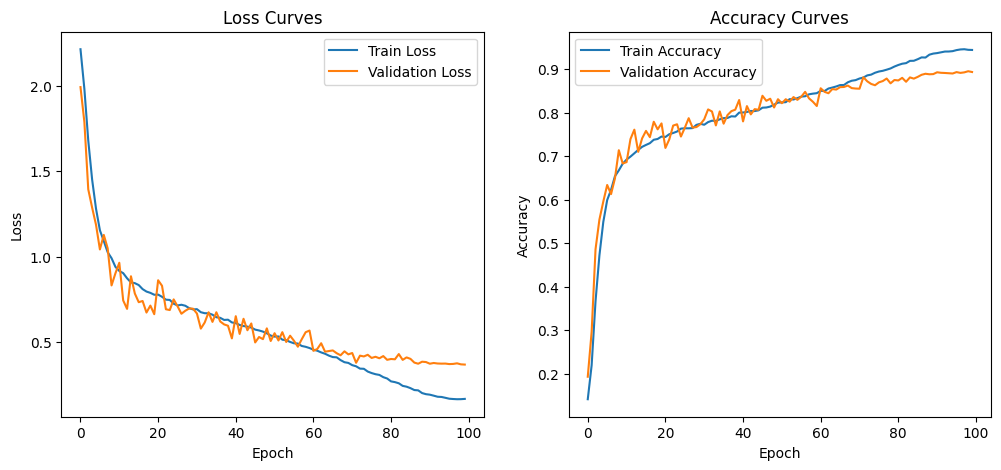

In [19]:
# Plot loss curves.
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

# Plot accuracy curves.
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()
plt.show()

## 8. Visualize Predicted vs. Ground Truth on Test Images

The following code is for you to explore the predictions vs. the ground truth. 
Some variables might be different from your implementation, so so might need to adjust it

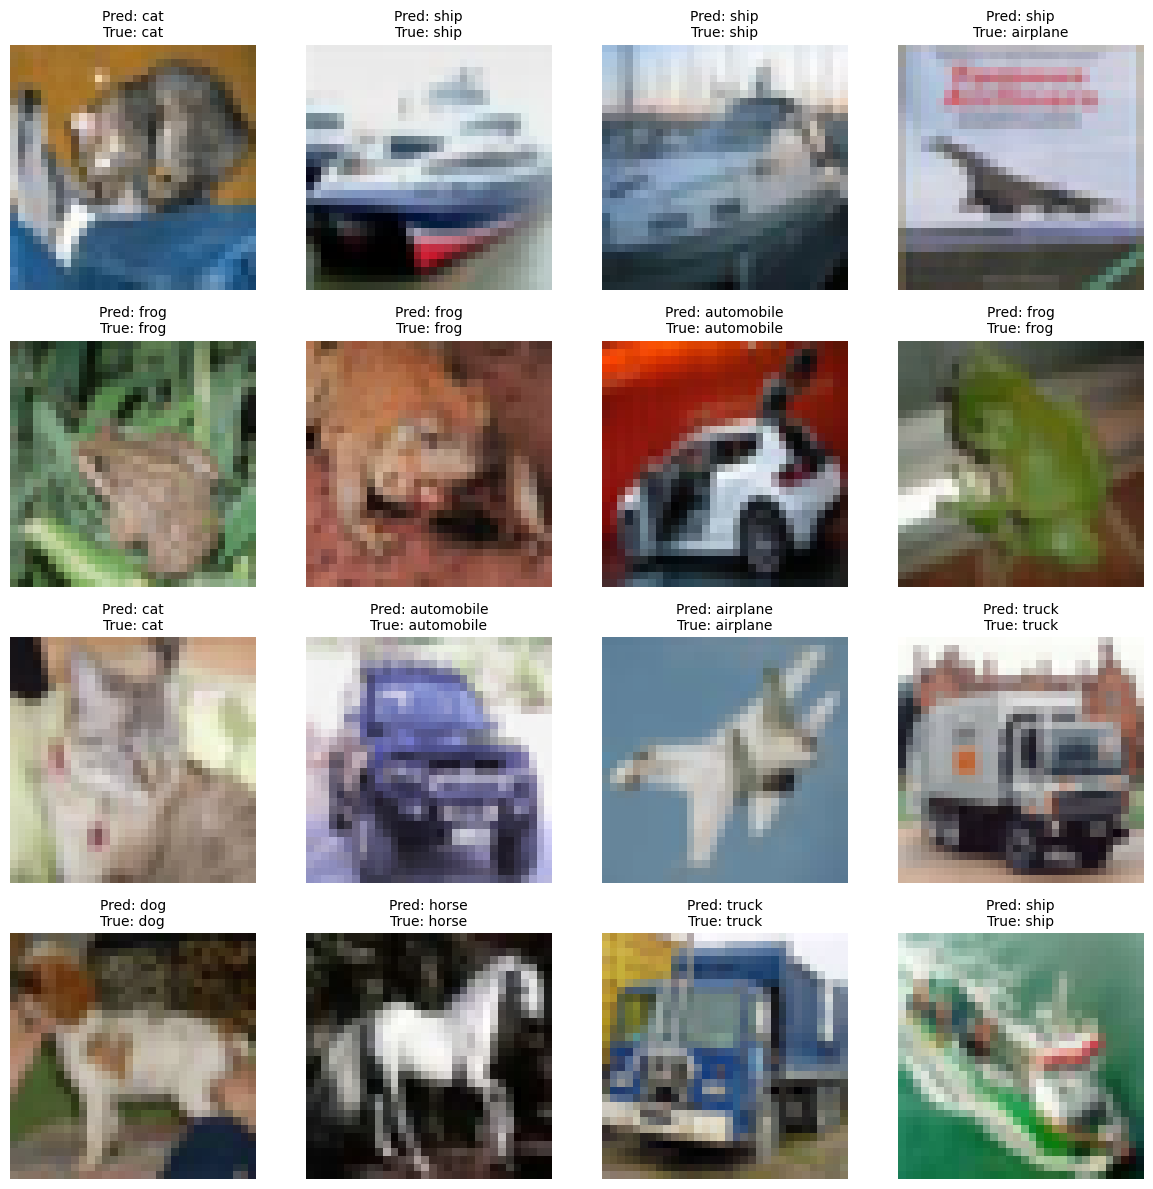

In [20]:
# CIFAR-10 class names.
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

def visualize_predictions(model, dataloader, class_names, num_images=16):
    """
    Visualizes a grid of images from the dataloader along with the model's predictions
    and the ground truth labels.
    """
    model.eval()
    images, labels = next(iter(dataloader))
    images = images.to(device)
    labels = labels.to(device)
    
    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
    
    images = images.cpu().numpy()
    labels = labels.cpu().numpy()
    preds = preds.cpu().numpy()

    plt.figure(figsize=(12, 12))
    for i in range(num_images):
        plt.subplot(4, 4, i + 1)
        # Convert image from [C, H, W] to [H, W, C].
        img = images[i].transpose(1, 2, 0)
        # Unnormalize the image (reverse the normalization applied during preprocessing).
        mean = np.array([0.4914, 0.4822, 0.4465])
        std = np.array([0.2470, 0.2435, 0.2616])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Pred: {class_names[preds[i]]}\nTrue: {class_names[labels[i]]}", fontsize=10)
    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_loader, class_names, num_images=16)

**Task 12. Answer the following questions:**

1. Why are convolutional layers used in CNNs instead of fully connected layers, and how do they help in image processing?
2. Define the terms receptive field, feature map, and kernel in your own words and explain their roles in convolutional layers.
3. What is the mathematical definition of a convolution and how does it explain the activation of feature maps?
3. How does pooling (e.g., max pooling, average pooling) contribute to CNN performance, and what are its advantages and potential downsides?
4. Explain the significance of padding and stride in convolutional operations. How do they impact the output size of feature maps?
5. How does a CNN progressively learn hierarchical representations of an image?
6. What are some common techniques for visualizing how CNNs learn features?
7. What is the difference between object detection and image segmentation and how they are related to CNNs?
8. How can CNNs be fooled by adversarial attacks, and what techniques exist to make them more robust?

1. Convolutional layers are better for image processing because:
- **Parameter sharing**: One 3x3 filter is shared across the entire image, reducing parameters massively
- **Spatial locality**: Captures local patterns like edges and textures 
- **Translation invariance**: Detects features regardless of their position in the image
- **Reduced overfitting**: Fewer parameters mean less chance of memorizing training data

Fully connected layers would require millions of parameters for each image pixel, making training computationally expensive and prone to overfitting.

2. Receptive Field is like a window, the information you get depends on the size

    kernel is a matrix and the weights inside will update automaticlly

    feature map is the output of the Input × Kernel it contains the most important information of each Receptive Field

3.  math$$(f * g)(x,y) = ΣΣ f(i,j) × g(x-i, y-j)$$ 

4. **Max Pooling:**
    - **Advantages**: Preserves strongest features, provides translation invariance, reduces computational cost, increases receptive field
    - **Disadvantages**: Loses spatial information, may discard important subtle features

    **Average Pooling:**  
    - **Advantages**: Retains more information, reduces overfitting, smoother feature transitions
    - **Disadvantages**: May blur important features, less effective at preserving dominant patterns

    Both techniques help CNNs become more robust to small translations and reduce the risk of overfitting by downsampling feature maps.

5. Padding is we add a "black frame" outside the picture, its  for cotroll the size of the output and also make sure the pixels at the edge also goes into the model
   
    Stride is like how fast you move the "window" and bigger Stride make the output smaller

    $$Output = (Input + 2×padding - kernel  size) / stride + 1$$

6. level1 edge

    level2 corner

    level3 shape or detail(more and more information)

    level4 the object

7. 
    - **Filter Visualization**: Display learned convolutional kernel weights to see what patterns they detect
    - **Feature Map Visualization**: Show activation maps at different layers to understand what features are being extracted
    - **Activation Maximization**: Find input patterns that maximally activate specific neurons
    - **Grad-CAM**: Generate heatmaps showing which image regions the model focuses on for predictions
    - **t-SNE/UMAP**: Visualize high-dimensional feature representations in 2D/3D space
    - **Layer-wise Relevance Propagation**: Trace back predictions to understand pixel-level contributions

    These techniques help interpret what CNNs learn and debug model behavior.

8. **Object Detection vs Image Segmentation:**

**Object Detection:**
- **Task**: Locate objects and classify them
- **Output**: Bounding boxes + class labels + confidence scores
- **Example**: "2 cats detected at coordinates [x1,y1,w1,h1] and [x2,y2,w2,h2]"
- **Algorithms**: YOLO, R-CNN, SSD

**Image Segmentation:**

*Semantic Segmentation:*
- **Task**: Classify each pixel by category
- **Output**: Pixel-wise class labels
- **Example**: Every pixel labeled as "cat", "background", "grass"

*Instance Segmentation:*
- **Task**: Separate different instances of the same class
- **Output**: Pixel-wise labels + instance IDs  
- **Example**: Pixel labeled as "cat_1" vs "cat_2"

**Relationship to CNNs:**
Both use CNN backbones (like ResNet) for feature extraction, but differ in their output heads:
- Object detection adds classification + regression heads
- Segmentation adds pixel-wise classification heads

9. **Adversarial Attacks and Defense:**

**How CNNs can be fooled:**
CNNs are vulnerable to small, carefully crafted perturbations that are imperceptible to humans but cause misclassification.

**Attack Methods:**
- **FGSM (Fast Gradient Sign Method)**: Single-step attack using gradient direction
- **PGD (Projected Gradient Descent)**: Multi-step iterative attack
- **C&W Attack**: Minimizes perturbation while ensuring attack success
- **Physical Attacks**: Real-world adversarial patches and objects

**Defense Techniques:**
- **Adversarial Training**: Train with both clean and adversarial examples
- **Defensive Distillation**: Use soft targets to make models less sensitive
- **Input Preprocessing**: Apply denoising, compression, or transformations
- **Detection Methods**: Identify adversarial examples before processing  
- **Model Ensemble**: Use multiple models and vote on predictions
- **Gradient Masking Prevention**: Avoid hiding gradients which gives false security

**Robustness Challenges:**
Perfect defense remains an open problem as attackers can adapt to new defenses. The arms race continues between attack and defense methods.